<a href="https://colab.research.google.com/github/nadiachwdhury/-learning-web-technologies-spring-2024-2025/blob/main/CNN_22_46735_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN Development on CIFAR-10 Dataset

This notebook demonstrates a complete CNN pipeline using PyTorch.

Steps:
1. Import Libraries
2. Load Dataset
3. Data Preprocessing
4. Build CNN Model
5. Training
6. Evaluation
7. Visualization
8. Save Model


In [1]:
# Import Libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns


## Load and Preprocess Dataset

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

classes = trainset.classes
print(classes)


100%|██████████| 170M/170M [00:03<00:00, 45.2MB/s]


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Define CNN Model

In [3]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3)

        self.fc1 = nn.Linear(64 * 6 * 6, 128)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(-1, 64 * 6 * 6)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

model = CNN()
print(model)


CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=2304, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


## Loss Function and Optimizer

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


## Training the Model

In [5]:
train_losses = []

for epoch in range(5):
    running_loss = 0.0

    for images, labels in trainloader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader)}")
    train_losses.append(running_loss/len(trainloader))


Epoch 1, Loss: 1.324356086804786
Epoch 2, Loss: 0.9649009320000693
Epoch 3, Loss: 0.8199655539472364
Epoch 4, Loss: 0.7089946626167761
Epoch 5, Loss: 0.6261632166092623


## Plot Training Loss

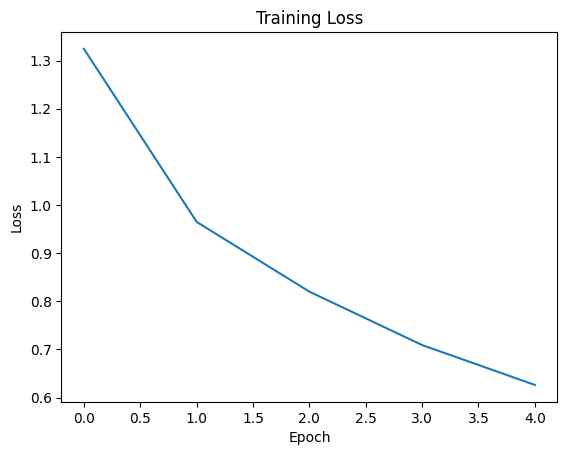

In [6]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()



## Model Evaluation

In [7]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total}%")


Accuracy: 71.32%


## Confusion Matrix

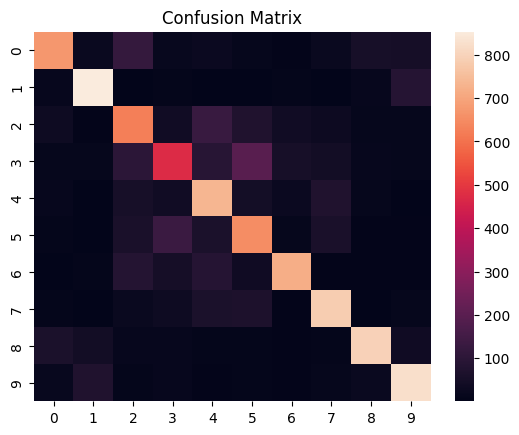

In [8]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm)
plt.title("Confusion Matrix")
plt.show()


## Save Model

In [9]:
torch.save(model.state_dict(), "model.pth")
print("Model saved successfully!")


Model saved successfully!
